# 02 — Segmentación de lesiones con U-Net/ResNet34

**Proyecto:** Skin Lesion Analysis  
**Repositorio:** https://github.com/Jesusrodriguezf90/skin-lesion-analysis  
**Fase:** Entrenamiento del modelo de segmentación

---

Este notebook entrena un U-Net con encoder ResNet34 preentrenado en ImageNet
para segmentar lesiones cutáneas píxel a píxel sobre el dataset ISIC 2018 Task 1.

El modelo entrenado se publica en HF Hub y se usa como primera etapa del pipeline
en `03_classification.ipynb` y en la demo Gradio.

In [1]:
"""
Notebook: 02_segmentation.ipynb

Objetivo:
    Entrenar un U-Net con encoder ResNet34 preentrenado en ImageNet para
    segmentación binaria de lesiones cutáneas dermoscópicas.

    La segmentación es la primera etapa del pipeline: delimita píxel a píxel
    la región de la lesión para que EfficientNet clasifique sobre ella y no
    sobre el fondo de piel sana.

Decisiones de diseño:
    - Resolución de entrada: 256×256. Compromiso entre detalle preservado y
      memoria GPU disponible en T4. 224×224 pierde demasiado detalle en bordes
      finos de lesión dado el factor de compresión ~14x desde la resolución
      original. 512×512 obliga a batch size ≤4, alargando el entrenamiento
      sin mejora proporcional con solo 2.594 imágenes.
    - Split: 80/20 con semilla fija (seed=42). Estándar en literatura ISIC 2018.
    - Loss: Dice + BCE combinadas. Dice optimiza el solapamiento directo con
      la máscara; BCE estabiliza el gradiente en las primeras épocas.
    - Early stopping: paciencia=10 épocas monitorizando Dice en validación.
      Evita overfitting con un dataset pequeño (2.075 imágenes de entrenamiento).
    - Optimizer: AdamW con lr=1e-4. Weight decay previene overfitting.
    - Scheduler: ReduceLROnPlateau — reduce lr cuando Dice val se estanca.

Dataset:
    ISIC 2018 Task 1 — 2.594 imágenes dermoscópicas + máscaras de segmentación
    https://challenge.isic-archive.com/data/#2018

Autor:   Jesús Rodríguez
Fecha:   2026-06-03
Versión: 1.0.0
"""

'\nNotebook: 02_segmentation.ipynb\n\nObjetivo:\n    Entrenar un U-Net con encoder ResNet34 preentrenado en ImageNet para\n    segmentación binaria de lesiones cutáneas dermoscópicas.\n\n    La segmentación es la primera etapa del pipeline: delimita píxel a píxel\n    la región de la lesión para que EfficientNet clasifique sobre ella y no\n    sobre el fondo de piel sana.\n\nDecisiones de diseño:\n    - Resolución de entrada: 256×256. Compromiso entre detalle preservado y\n      memoria GPU disponible en T4. 224×224 pierde demasiado detalle en bordes\n      finos de lesión dado el factor de compresión ~14x desde la resolución\n      original. 512×512 obliga a batch size ≤4, alargando el entrenamiento\n      sin mejora proporcional con solo 2.594 imágenes.\n    - Split: 80/20 con semilla fija (seed=42). Estándar en literatura ISIC 2018.\n    - Loss: Dice + BCE combinadas. Dice optimiza el solapamiento directo con\n      la máscara; BCE estabiliza el gradiente en las primeras épocas.\n  

## 1. Configuración del entorno

In [2]:
# Detección del entorno de ejecución (Kaggle vs local)
import os

IN_KAGGLE = os.path.exists("/kaggle/input")
print(f"Entorno detectado: {"Kaggle" if IN_KAGGLE else "local"}")

Entorno detectado: Kaggle


In [3]:
# Verificación del entorno y GPU disponible
import sys
import platform
import torch

print(f"Python  : {sys.version}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Python  : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


## 2. Instalación de dependencias

In [4]:
# Instalación de dependencias de segmentación médica
# Se instalan en modo silencioso (-q) para reducir el output en Kaggle
%pip install segmentation-models-pytorch albumentations -q

Note: you may need to restart the kernel to use updated packages.


In [5]:
# Verificación de imports principales
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

print("Dependencias importadas correctamente")

Dependencias importadas correctamente


## 3. Reproducibilidad y configuración global

In [6]:
# Semilla global para reproducibilidad completa del experimento
SEED = 42

def set_seed(seed: int) -> None:
    """Fija la semilla en todos los generadores aleatorios del stack.

    Args:
        seed: Valor entero de la semilla.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
print(f"Semilla fijada: {SEED}")

Semilla fijada: 42


In [7]:
# Hiperparámetros del experimento — centralizados para facilitar ajustes
CFG = {
    "img_size"    : 256,       # resolución de entrada — ver justificación en docstring
    "batch_size"  : 16,        # T4 (15GB): 16 es el máximo viable a 256×256 con ResNet34
    "num_workers" : 2,
    "epochs"      : 25,        # early stopping detiene antes si no hay mejora
    "lr"          : 1e-4,
    "weight_decay": 1e-4,
    "val_split"   : 0.2,       # 80/20 — estándar en literatura ISIC 2018
    "patience"    : 5,        # épocas sin mejora antes de detener el entrenamiento
    "encoder"     : "resnet34",
    "encoder_weights": "imagenet",
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo : {DEVICE}")
print(f"Config      : {CFG}")

Dispositivo : cuda
Config      : {'img_size': 256, 'batch_size': 16, 'num_workers': 2, 'epochs': 25, 'lr': 0.0001, 'weight_decay': 0.0001, 'val_split': 0.2, 'patience': 5, 'encoder': 'resnet34', 'encoder_weights': 'imagenet'}


## 4. Definición de rutas

In [8]:
# Rutas del dataset — estructura consistente con 01_eda.ipynb
if IN_KAGGLE:
    DIR_INPUT  = Path("/kaggle/input/datasets/jesusrf1990/isic2018-skin-lesion")
    DIR_OUTPUT = Path("/kaggle/working")
else:
    DIR_INPUT  = Path("data/raw")
    DIR_OUTPUT = Path("data/processed")

DIR_IMAGENES = DIR_INPUT / "ISIC2018_Task1-2_Training_Input"
DIR_MASCARAS = DIR_INPUT / "ISIC2018_Task1_Training_GroundTruth"
DIR_OUTPUT.mkdir(parents=True, exist_ok=True)

# Validación de existencia de las rutas antes de continuar
assert DIR_IMAGENES.exists(), f"No se encontró el directorio de imágenes: {DIR_IMAGENES}"
assert DIR_MASCARAS.exists(), f"No se encontró el directorio de máscaras: {DIR_MASCARAS}"

imagenes = sorted(DIR_IMAGENES.glob("*.jpg"))
mascaras = sorted(DIR_MASCARAS.glob("*.png"))

print(f"Imágenes : {len(imagenes)}")
print(f"Máscaras : {len(mascaras)}")

Imágenes : 2594
Máscaras : 2594


## 5. Dataset y data augmentation

In [9]:
def get_transforms(img_size: int, train: bool) -> A.Compose:
    """Devuelve el pipeline de data augmentation para train o validación.

    Args:
        img_size: Resolución de salida (ancho = alto).
        train:    True para data augmentation, False para solo resize + normalización.

    Returns:
        Pipeline de Albumentations listo para aplicar.

    Notes:
        Normalización con media/std de ImageNet — el encoder ResNet34 fue
        preentrenado con estas estadísticas y espera el mismo rango.
        Las data augmentations geométricas y de color son estándar en CV médico
        para aumentar la variabilidad con datasets pequeños.
    """
    if train:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ])
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

In [10]:
class ISICSegmentationDataset(Dataset):
    """Dataset PyTorch para segmentación binaria de lesiones ISIC 2018 Task 1.

    Args:
        rutas_img:  Lista de rutas a las imágenes .jpg.
        dir_masks:  Directorio que contiene las máscaras _segmentation.png.
        transform:  Pipeline de Albumentations a aplicar.

    Notes:
        Las máscaras se binariza con umbral 127 — el ground truth de ISIC
        es binario (0/255) pero puede tener artefactos de compresión JPEG.
    """

    def __init__(self, rutas_img: list, dir_masks: Path, transform=None):
        self.rutas_img  = rutas_img
        self.dir_masks  = dir_masks
        self.transform  = transform

    def __len__(self) -> int:
        return len(self.rutas_img)

    def __getitem__(self, idx: int) -> tuple:
        ruta_img  = self.rutas_img[idx]
        ruta_mask = self.dir_masks / (ruta_img.stem + "_segmentation.png")

        img  = np.array(Image.open(ruta_img).convert("RGB"))
        mask = np.array(Image.open(ruta_mask).convert("L"))

        # Binarización de la máscara — float32 requerido por la loss
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img  = augmented["image"]
            mask = augmented["mask"].unsqueeze(0)  # (1, H, W)

        return img, mask

In [11]:
# Split 80/20 con semilla fija — reproducible entre ejecuciones
n_total = len(imagenes)
n_val   = int(n_total * CFG["val_split"])
n_train = n_total - n_val

# Shuffle determinista antes de partir
indices = list(range(n_total))
random.shuffle(indices)

rutas_train = [imagenes[i] for i in indices[:n_train]]
rutas_val   = [imagenes[i] for i in indices[n_train:]]

ds_train = ISICSegmentationDataset(rutas_train, DIR_MASCARAS, get_transforms(CFG["img_size"], train=True))
ds_val   = ISICSegmentationDataset(rutas_val,   DIR_MASCARAS, get_transforms(CFG["img_size"], train=False))

dl_train = DataLoader(ds_train, batch_size=CFG["batch_size"], shuffle=True,  num_workers=CFG["num_workers"], pin_memory=True)
dl_val   = DataLoader(ds_val,   batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"], pin_memory=True)

print("=" * 45)
print("SPLIT DEL DATASET")
print("=" * 45)
print(f"  Total       : {n_total}")
print(f"  Entrenamiento: {n_train}")
print(f"  Validación  : {n_val}")
print(f"  Batches train: {len(dl_train)}")
print(f"  Batches val  : {len(dl_val)}")
print("=" * 45)

SPLIT DEL DATASET
  Total       : 2594
  Entrenamiento: 2076
  Validación  : 518
  Batches train: 130
  Batches val  : 33


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 6. Modelo

In [12]:
# U-Net con encoder ResNet34 preentrenado en ImageNet
# segmentation-models-pytorch abstrae la arquitectura completa —
# el encoder actúa como backbone y el decoder reconstruye la máscara
model = smp.Unet(
    encoder_name    = CFG["encoder"],
    encoder_weights = CFG["encoder_weights"],
    in_channels     = 3,
    classes         = 1,           # máscara binaria
    activation      = None,        # sigmoid se aplica en la loss
).to(DEVICE)

# Conteo de parámetros
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 45)
print("MODELO — U-Net/ResNet34")
print("=" * 45)
print(f"  Parámetros totales    : {total_params:,}")
print(f"  Parámetros entrenables: {trainable_params:,}")
print("=" * 45)

MODELO — U-Net/ResNet34
  Parámetros totales    : 24,436,369
  Parámetros entrenables: 24,436,369


In [13]:
dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss  = smp.losses.SoftBCEWithLogitsLoss()

def loss_fn(pred, target):
    """Loss combinada Dice + BCE — ver justificación en docstring del notebook."""
    return dice_loss(pred, target) + bce_loss(pred, target)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = CFG["lr"],
    weight_decay = CFG["weight_decay"],
)

# ReduceLROnPlateau — reduce lr x10 cuando Dice val no mejora en 5 épocas
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.1, patience=5
)

print("Loss, optimizer y scheduler configurados")


Loss, optimizer y scheduler configurados


## 7. Funciones de entrenamiento y validación

In [14]:
def dice_coefficient(pred: torch.Tensor, target: torch.Tensor, threshold: float = 0.5) -> float:
    """Calcula el coeficiente Dice entre predicción y ground truth.

    Args:
        pred:      Tensor de predicciones con logits (B, 1, H, W).
        target:    Tensor de máscaras ground truth (B, 1, H, W).
        threshold: Umbral para binarizar la predicción.

    Returns:
        Dice medio del batch como float.

    Notes:
        Smooth=1 evita división por cero en máscaras vacías.
    """
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    smooth   = 1.0
    intersec = (pred_bin * target).sum(dim=(2, 3))
    dice     = (2.0 * intersec + smooth) / (pred_bin.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) + smooth)
    return dice.mean().item()


def iou_coefficient(pred: torch.Tensor, target: torch.Tensor, threshold: float = 0.5) -> float:
    """Calcula el índice IoU (Jaccard) entre predicción y ground truth.

    Args:
        pred:      Tensor de predicciones con logits (B, 1, H, W).
        target:    Tensor de máscaras ground truth (B, 1, H, W).
        threshold: Umbral para binarizar la predicción.

    Returns:
        IoU medio del batch como float.
    """
    pred_bin  = (torch.sigmoid(pred) > threshold).float()
    smooth    = 1.0
    intersec  = (pred_bin * target).sum(dim=(2, 3))
    union     = pred_bin.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) - intersec
    iou       = (intersec + smooth) / (union + smooth)
    return iou.mean().item()


print("Métricas definidas: Dice, IoU")

Métricas definidas: Dice, IoU


In [15]:
def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
) -> tuple[float, float]:
    """Ejecuta una época de entrenamiento.

    Args:
        model:     Modelo U-Net en modo train.
        loader:    DataLoader de entrenamiento.
        optimizer: Optimizador AdamW.

    Returns:
        Tupla (loss_media, dice_medio) de la época.
    """
    model.train()
    total_loss, total_dice = 0.0, 0.0

    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        preds = model(imgs)
        loss  = loss_fn(preds, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_dice += dice_coefficient(preds, masks)

    n = len(loader)
    return total_loss / n, total_dice / n


@torch.no_grad()
def val_epoch(
    model: nn.Module,
    loader: DataLoader,
) -> tuple[float, float, float]:
    """Ejecuta una época de validación sin gradientes.

    Args:
        model:  Modelo U-Net en modo eval.
        loader: DataLoader de validación.

    Returns:
        Tupla (loss_media, dice_medio, iou_medio) de la época.
    """
    model.eval()
    total_loss, total_dice, total_iou = 0.0, 0.0, 0.0

    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds       = model(imgs)
        loss        = loss_fn(preds, masks)

        total_loss += loss.item()
        total_dice += dice_coefficient(preds, masks)
        total_iou  += iou_coefficient(preds, masks)

    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n


print("Funciones de entrenamiento y validación definidas")

Funciones de entrenamiento y validación definidas


## 8. Entrenamiento con early stopping

In [16]:
# Historial de métricas para las curvas de aprendizaje
historial = {
    "train_loss": [], "train_dice": [],
    "val_loss"  : [], "val_dice"  : [], "val_iou": [],
}

# Estado del early stopping
mejor_dice     = 0.0
epocas_sin_mejora = 0
ruta_mejor_modelo = DIR_OUTPUT / "best_unet_resnet34.pth"

print(f"Entrenando {CFG['epochs']} épocas máx. — early stopping paciencia={CFG['patience']}")
print(f"Modelo guardado en: {ruta_mejor_modelo}")
print("=" * 65)

Entrenando 25 épocas máx. — early stopping paciencia=5
Modelo guardado en: /kaggle/working/best_unet_resnet34.pth


In [17]:
for epoca in range(1, CFG["epochs"] + 1):

    train_loss, train_dice           = train_epoch(model, dl_train, optimizer)
    val_loss,   val_dice,   val_iou  = val_epoch(model, dl_val)

    # Actualizar scheduler con Dice de validación
    scheduler.step(val_dice)

    # Registrar métricas
    historial["train_loss"].append(train_loss)
    historial["train_dice"].append(train_dice)
    historial["val_loss"].append(val_loss)
    historial["val_dice"].append(val_dice)
    historial["val_iou"].append(val_iou)

    print(f"Época {epoca:>3}/{CFG['epochs']} | "
          f"Train loss: {train_loss:.4f} dice: {train_dice:.4f} | "
          f"Val loss: {val_loss:.4f} dice: {val_dice:.4f} iou: {val_iou:.4f}")

    # Guardar el mejor modelo según Dice en validación
    if val_dice > mejor_dice:
        mejor_dice = val_dice
        epocas_sin_mejora = 0
        torch.save(model.state_dict(), ruta_mejor_modelo)
        print(f"  → Nuevo mejor modelo guardado (Dice val: {mejor_dice:.4f})")
    else:
        epocas_sin_mejora += 1

    # Early stopping
    if epocas_sin_mejora >= CFG["patience"]:
        print(f"\nEarly stopping en época {epoca} — sin mejora en {CFG['patience']} épocas")
        break

print("=" * 65)
print(f"Entrenamiento completado — mejor Dice val: {mejor_dice:.4f}")

Época   1/25 | Train loss: 0.8381 dice: 0.7147 | Val loss: 0.6150 dice: 0.8467 iou: 0.7535
  → Nuevo mejor modelo guardado (Dice val: 0.8467)
Época   2/25 | Train loss: 0.5923 dice: 0.8299 | Val loss: 0.4919 dice: 0.8750 iou: 0.7936
  → Nuevo mejor modelo guardado (Dice val: 0.8750)
Época   3/25 | Train loss: 0.4520 dice: 0.8586 | Val loss: 0.3986 dice: 0.8841 iou: 0.8049
  → Nuevo mejor modelo guardado (Dice val: 0.8841)
Época   4/25 | Train loss: 0.3767 dice: 0.8704 | Val loss: 0.3208 dice: 0.8927 iou: 0.8222
  → Nuevo mejor modelo guardado (Dice val: 0.8927)
Época   5/25 | Train loss: 0.3261 dice: 0.8771 | Val loss: 0.3270 dice: 0.8923 iou: 0.8229
Época   6/25 | Train loss: 0.3086 dice: 0.8765 | Val loss: 0.2973 dice: 0.8907 iou: 0.8190
Época   7/25 | Train loss: 0.2739 dice: 0.8852 | Val loss: 0.2503 dice: 0.8982 iou: 0.8293
  → Nuevo mejor modelo guardado (Dice val: 0.8982)
Época   8/25 | Train loss: 0.2492 dice: 0.8896 | Val loss: 0.2487 dice: 0.8956 iou: 0.8265
Época   9/25 | Tr

## 9. Curvas de aprendizaje

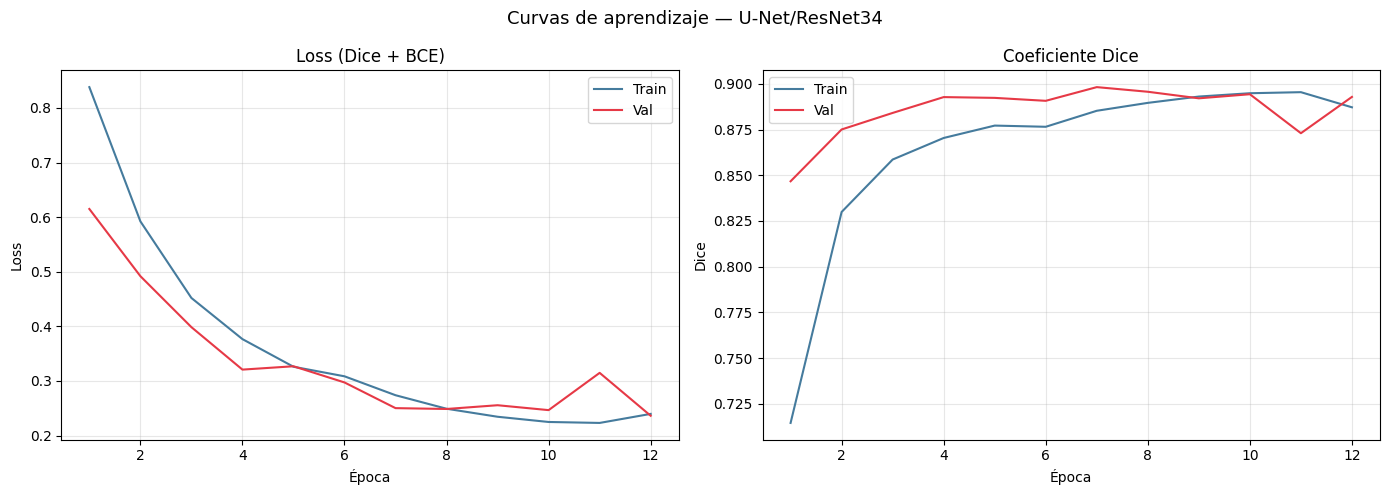

In [18]:
# Visualización de la evolución de loss y Dice durante el entrenamiento
epocas = range(1, len(historial["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epocas, historial["train_loss"], label="Train", color="#457b9d")
axes[0].plot(epocas, historial["val_loss"],   label="Val",   color="#e63946")
axes[0].set_title("Loss (Dice + BCE)")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Dice
axes[1].plot(epocas, historial["train_dice"], label="Train", color="#457b9d")
axes[1].plot(epocas, historial["val_dice"],   label="Val",   color="#e63946")
axes[1].set_title("Coeficiente Dice")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Dice")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Curvas de aprendizaje — U-Net/ResNet34", fontsize=13)
plt.tight_layout()
plt.savefig(DIR_OUTPUT / "curvas_aprendizaje.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Evaluación final

In [19]:
# Cargar el mejor modelo guardado durante el entrenamiento
model.load_state_dict(torch.load(ruta_mejor_modelo, map_location=DEVICE))

val_loss_final, val_dice_final, val_iou_final = val_epoch(model, dl_val)

print("=" * 50)
print("EVALUACIÓN FINAL — MEJOR MODELO")
print("=" * 50)
print(f"  Loss  : {val_loss_final:.4f}")
print(f"  Dice  : {val_dice_final:.4f}")
print(f"  IoU   : {val_iou_final:.4f}")
print("=" * 50)

EVALUACIÓN FINAL — MEJOR MODELO
  Loss  : 0.2503
  Dice  : 0.8982
  IoU   : 0.8293


## 11. Visualización de predicciones

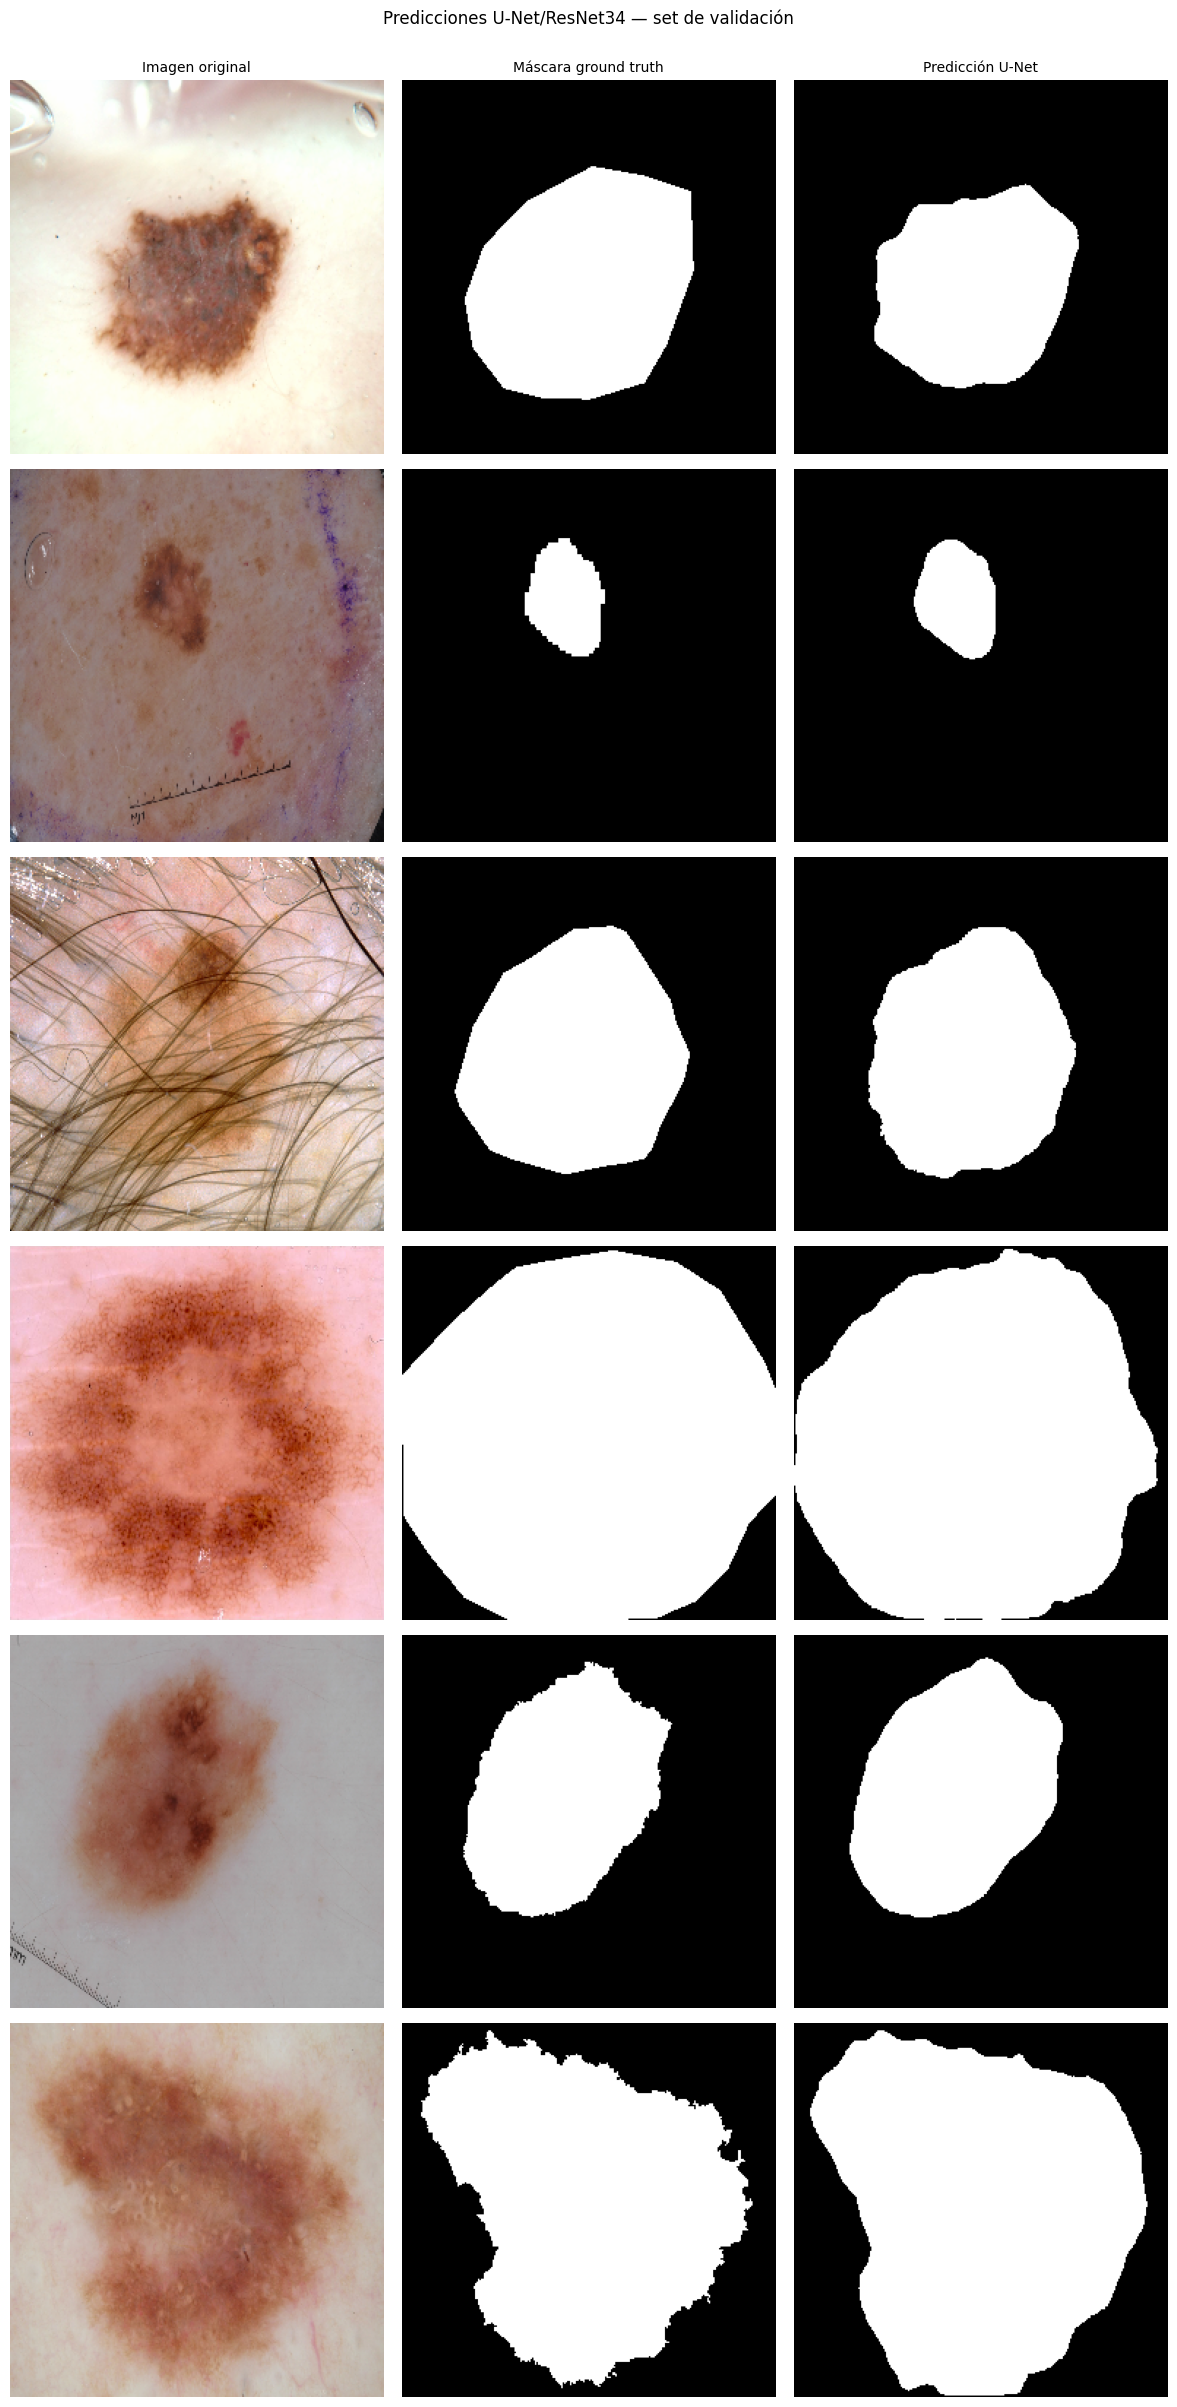

In [20]:
# Visualización de 6 predicciones del mejor modelo sobre el set de validación
# Permite inspeccionar visualmente la calidad de la segmentación
model.eval()

fig, axes = plt.subplots(6, 3, figsize=(12, 24))
axes[0, 0].set_title("Imagen original", fontsize=10)
axes[0, 1].set_title("Máscara ground truth", fontsize=10)
axes[0, 2].set_title("Predicción U-Net", fontsize=10)

# Media y std de ImageNet para desnormalizar la imagen antes de visualizar
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

muestra_val = random.sample(list(range(len(ds_val))), 6)

with torch.no_grad():
    for i, idx in enumerate(muestra_val):
        img_t, mask_t = ds_val[idx]

        pred = torch.sigmoid(model(img_t.unsqueeze(0).to(DEVICE)))
        pred_bin = (pred > 0.5).float().squeeze().cpu().numpy()

        # Desnormalizar imagen para visualización
        img_np = img_t.permute(1, 2, 0).numpy()
        img_np = np.clip(img_np * STD + MEAN, 0, 1)

        axes[i, 0].imshow(img_np)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask_t.squeeze().numpy(), cmap="gray")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred_bin, cmap="gray")
        axes[i, 2].axis("off")

plt.suptitle("Predicciones U-Net/ResNet34 — set de validación", fontsize=12, y=1.001)
plt.tight_layout()
plt.savefig(DIR_OUTPUT / "predicciones_segmentacion.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Publicación del modelo en HF Hub

In [27]:
# Subida del modelo al HF Hub para uso en el pipeline de inferencia
# y en la demo Gradio
from huggingface_hub import HfApi
import os

from kaggle_secrets import UserSecretsClient
HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
HF_REPO   = "Jesusrodriguezf90/unet-resnet34-isic2018-segmentation"

assert HF_TOKEN, "HF_TOKEN no encontrado — añádelo en Kaggle > Add-ons > Secrets"

api = HfApi()

# Crear el repositorio si no existe
api.create_repo(repo_id=HF_REPO, token=HF_TOKEN, exist_ok=True)

# Subir el modelo
api.upload_file(
    path_or_fileobj = str(ruta_mejor_modelo),
    path_in_repo    = "best_unet_resnet34.pth",
    repo_id         = HF_REPO,
    token           = HF_TOKEN,
)

print(f"Modelo publicado en: https://huggingface.co/{HF_REPO}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Modelo publicado en: https://huggingface.co/Jesusrodriguezf90/unet-resnet34-isic2018-segmentation


## 13. Resumen

In [26]:
# Resumen del experimento
print("=" * 60)
print("RESUMEN — SEGMENTACIÓN U-Net/ResNet34")
print("=" * 60)
print(f"  Resolución entrada    : {CFG['img_size']}×{CFG['img_size']}")
print(f"  Imágenes entrenamiento: {n_train}")
print(f"  Imágenes validación   : {n_val}")
print(f"  Épocas ejecutadas     : {len(historial['train_loss'])}")
print(f"  Mejor Dice val        : {val_dice_final:.4f}")
print(f"  Mejor IoU val         : {val_iou_final:.4f}")
print(f"  Modelo en HF Hub      : {HF_REPO}")
print("=" * 60)
print("Siguiente paso: 03_classification.ipynb")

RESUMEN — SEGMENTACIÓN U-Net/ResNet34
  Resolución entrada    : 256×256
  Imágenes entrenamiento: 2076
  Imágenes validación   : 518
  Épocas ejecutadas     : 12
  Mejor Dice val        : 0.8982
  Mejor IoU val         : 0.8293
  Modelo en HF Hub      : Jesusrodriguezf90/unet-resnet34-isic2018-segmentation
Siguiente paso: 03_classification.ipynb
